# 01 · Frames: world, structural, hover, rotor and sensor

Every vector in the simulator is a list of three numbers, and those numbers only mean something once you know which axes they are measured along. This notebook goes through each frame the simulator uses and the rotations between them.

In [1]:
# Setup: make the repository importable and load the V3 airframe used throughout these notebooks
import sys, math, pathlib
ROOT = pathlib.Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from airframe_designer.geometry.airframe import Airframe

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.grid": True, "grid.alpha": 0.3})

AF_PATH = ROOT / "airframes" / "atlas_v3_v34_foils_50_65_50_tuned.json"
af = Airframe.load(AF_PATH)
af.resolve_mass()
G = 9.80665
print(f"{af.name}: {af.mass.mass:.2f} kg, {len(af.active_rotors())} fans, hover pitch {af.hover_pitch_deg} deg, parked {af.landed_pitch_deg} deg")

ATLAS_V3_V34_FOILS_50_65_50_TUNED: 11.83 kg, 9 fans, hover pitch 23.85 deg, parked 23.85 deg


## 1. The world frame and why it can be treated as inertial

**Theory.** Newton's law $\mathbf F = m\mathbf a$ holds as written only in an inertial frame. Seen from a frame $B$ that rotates at $\boldsymbol\omega$, the rate of change of any vector $\mathbf b$ picks up an extra term (the transport theorem):

$$\left.\frac{d\mathbf b}{dt}\right|_I = \left.\frac{d\mathbf b}{dt}\right|_B + \boldsymbol\omega\times\mathbf b .$$

Applied to motion over the rotating Earth, the acceleration gains a Coriolis and a centripetal term:

$$\mathbf a_I = \mathbf a_E + 2\,\boldsymbol\Omega_E\times\mathbf v_E + \boldsymbol\Omega_E\times(\boldsymbol\Omega_E\times\mathbf r),\qquad \Omega_E = 7.29\times10^{-5}\ \text{rad/s}.$$

The simulator uses a **flat, non-rotating North-East-Down** frame with its origin on the floor at the home point, and drops both terms. The cell below shows how small they are for ATLAS.

> **Note: what "inertial" means here**
>
> An inertial frame is one that is not accelerating or spinning. The room is not quite one, because the Earth spins once a day. But the Earth spins so slowly that, for an aircraft moving at walking speed for a few minutes, the effect is tens of thousands of times smaller than gravity. So the simulator pretends the room is perfectly still and flat, which keeps the equations simple.

In [2]:
Omega_E, R_E = 7.2921e-5, 6.371e6
for v in (0.5, 2.0, 5.0):
    cor = 2 * Omega_E * v
    print(f"Coriolis at {v:3.1f} m/s: {cor:.2e} m/s^2 = {cor / G:.1e} g")
cent = Omega_E**2 * R_E
print(f"Centripetal at the equator: {cent:.3f} m/s^2 = {100 * cent / G:.2f} % of g (constant, absorbed into g)")

Coriolis at 0.5 m/s: 7.29e-05 m/s^2 = 7.4e-06 g
Coriolis at 2.0 m/s: 2.92e-04 m/s^2 = 3.0e-05 g
Coriolis at 5.0 m/s: 7.29e-04 m/s^2 = 7.4e-05 g
Centripetal at the equator: 0.034 m/s^2 = 0.35 % of g (constant, absorbed into g)


## 2. The frames that move with the aircraft

| Frame | Axes and origin | Used for |
|---|---|---|
| **World** (NED) | North, East, Down; home point on the floor | position, velocity, gravity, wind, floor |
| **Structural** = simulator body frame | Forward, Right, Down (FRD), fixed to the CAD; moments about the CG | rotor geometry, inertia, forces, angular velocity, IMU |
| **Hover** = PX4 body frame | structural frame pitched nose-up by $\theta_h$ | what PX4 calls "level"; told with `SENS_BOARD_Y_OFF` |
| **Rotor** | position $\mathbf r_i$ and unit push direction $\hat{\mathbf a}_i$ of fan $i$, in structural axes | thrust and reaction torque; exported to PX4 in hover axes |
| **Sensor** | IMU in structural axes; H-FLOW fixed to the frame, tilted 20.4° | what each sensor reports |

> **Note: the hover frame**
>
> When ATLAS hovers still, its structure is tilted nose-up by 23.85°, because that is where the nine tilted jets balance. PX4 wants "level" to mean "hovering still", so it uses axes tilted along with the aircraft: in a hover, the hover frame's x axis is horizontal and its z axis points straight down. Stick centred, roll 0 and pitch 0 all refer to this frame.

## 3. The pitch rotation between structural and hover axes

**Theory.** A rotation about the y (wing) axis by $\theta_h$ leaves $y$ alone and mixes $x$ and $z$:

$$\mathbf v_{\text{hover}} = R_h\,\mathbf v_{\text{struct}},\qquad R_h = \begin{bmatrix}\cos\theta_h & 0 & \sin\theta_h\\ 0&1&0\\ -\sin\theta_h & 0 & \cos\theta_h\end{bmatrix},\qquad R_h^{-1} = R_h^{\mathsf T}.$$

`Airframe.hover_rotation()` builds exactly this matrix.

In [3]:
Rh = af.hover_rotation()
print("R_h =\n", Rh)
print("orthonormal (R_h R_h^T = I):", np.allclose(Rh @ Rh.T, np.eye(3)), "  det =", round(np.linalg.det(Rh), 6))
print("structural forward axis (1,0,0) in hover axes:", Rh @ [1, 0, 0])

R_h =
 [[ 0.9146  0.      0.4043]
 [ 0.      1.      0.    ]
 [-0.4043  0.      0.9146]]
orthonormal (R_h R_h^T = I): True   det = 1.0
structural forward axis (1,0,0) in hover axes: [ 0.9146  0.     -0.4043]


> **Note: reading the result**
>
> The structural nose axis comes out as (0.915, 0, −0.404) in hover axes. Negative z means up, so in a hover the nose points 0.40 upward for every 0.915 forward: that is the 23.85° nose-up attitude seen from PX4's level frame.

### A measurement from the board (30 Sep, HITL)

Parked at −16°, the Pixhawk's raw accelerometer (structural axes) read $(-2.71, 0.04, -9.43)\ \text{m/s}^2$, and after PX4 applied its 23.85° board rotation it reported $(-6.26, 0.13, -7.52)$. The same rotation done by hand:

In [4]:
raw_struct = np.array([-2.71, 0.04, -9.43])
print("R_h @ raw   =", Rh @ raw_struct)
print("board said = [-6.26  0.13 -7.52]")

R_h @ raw   = [-6.2915  0.04   -7.529 ]
board said = [-6.26  0.13 -7.52]


## 4. The rotor frame: where each fan pushes, and in which direction

**Theory.** Fan $i$ is described by the point where its jet force acts, $\mathbf r_i$, and a unit push direction $\hat{\mathbf a}_i$. Its jetfoil turns the jet by the exit angle $\delta$, so the push is $\hat{\mathbf a} = (\cos\delta, 0, -\sin\delta)$ in structural axes (notebook 06). PX4 receives both in **hover axes, relative to the CG**: $R_h(\mathbf r_i - \mathbf r_{CG})$ and $R_h\hat{\mathbf a}_i$. `Airframe.rotors_in_px4_frame()` does that conversion.

In [5]:
cg = af.cg
print(f"{'fan':10s} {'exit deg':>8s}  {'push, structural':>24s}  {'push, hover':>24s}  {'up share':>8s}")
for r, (p_h, a_h) in zip(af.active_rotors(), af.rotors_in_px4_frame()):
    a_s = np.asarray(r.axis, float) / np.linalg.norm(r.axis)
    print(f"{r.name[:10]:10s} {r.deflection_deg():8.1f}  {str(np.round(a_s, 3)):>24s}  {str(np.round(a_h, 3)):>24s}  {-a_h[2]:8.3f}")

fan        exit deg          push, structural               push, hover  up share
M1             50.0    [ 0.643  0.    -0.766]    [ 0.278  0.    -0.961]     0.961
M2             50.0    [ 0.643  0.    -0.766]    [ 0.278  0.    -0.961]     0.961
M3             65.0    [ 0.423  0.    -0.906]       [ 0.02  0.   -1.  ]     1.000
M4             65.0    [ 0.423  0.    -0.906]       [ 0.02  0.   -1.  ]     1.000
M5             50.0    [ 0.643  0.    -0.766]    [ 0.278  0.    -0.961]     0.961
M6             50.0    [ 0.643  0.    -0.766]    [ 0.278  0.    -0.961]     0.961
M7              0.0    [ 0.     0.5   -0.866]    [-0.35   0.5   -0.792]     0.792
M8              0.0    [ 0.    -0.5   -0.866]    [-0.35  -0.5   -0.792]     0.792
M9              0.0             [ 0.  0. -1.]    [-0.404  0.    -0.915]     0.915


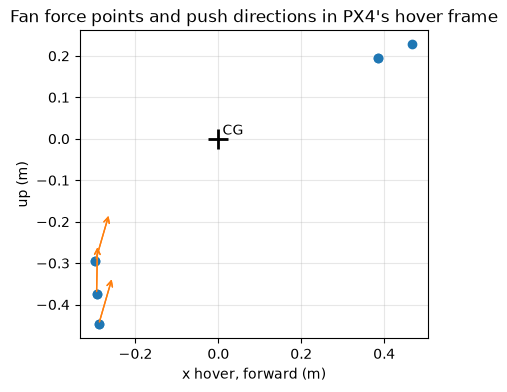

In [6]:
# Side view in hover axes (x forward, z down, so plot -z as up): each fan's position and push direction
fig, ax = plt.subplots(figsize=(7, 4))
for r, (p_h, a_h) in zip(af.active_rotors(), af.rotors_in_px4_frame()):
    ax.plot(p_h[0], -p_h[2], "o", color="C0")
    ax.annotate("", xy=(p_h[0] + 0.12 * a_h[0], -p_h[2] - 0.12 * a_h[2]), xytext=(p_h[0], -p_h[2]),
                arrowprops=dict(arrowstyle="->", color="C1"))
ax.plot(0, 0, "k+", ms=14, mew=2); ax.text(0.01, 0.01, "CG")
ax.set_xlabel("x hover, forward (m)"); ax.set_ylabel("up (m)"); ax.set_aspect("equal")
ax.set_title("Fan force points and push directions in PX4's hover frame")
plt.show()

> **Note: what PX4 does with these numbers**
>
> PX4's motor mixer is given these hover-axes positions and directions as `CA_ROTORi_PX/PY/PZ` and `CA_ROTORi_AX/AY/AZ`. From them it works out how much each fan contributes to roll, pitch, yaw and lift, and inverts that to decide which fans to speed up for a given command. If these numbers are wrong (for example in structural instead of hover axes), every command goes partly to the wrong axis.

## 5. A frame mismatch found on 30 Sep: the flow gyro

**Theory.** A pure yaw rotation at rate $r$ about the **hover** vertical is the vector $(0, 0, r)$ in hover axes. In structural axes it is $R_h^{\mathsf T}(0, 0, r) = (-r\sin\theta_h,\ 0,\ r\cos\theta_h)$. PX4's optical-flow module, when the flow sensor sends no gyro, integrates the raw gyro, which is in structural axes, and uses its x and y parts as roll and pitch rates.

In [7]:
yaw_rate = np.array([0, 0, 1.0])        # 1 rad/s about the hover vertical
seen_raw = Rh.T @ yaw_rate
print("yaw 1 rad/s seen by the raw gyro (structural axes):", np.round(seen_raw, 3))
print(f"=> {abs(seen_raw[0]) * 100:.0f} % of every yaw rate looks like a roll rate to the flow compensation")

yaw 1 rad/s seen by the raw gyro (structural axes): [-0.404  0.     0.915]
=> 40 % of every yaw rate looks like a roll rate to the flow compensation


> **Note: why it matters and what fixes it**
>
> The camera sees the floor move when the aircraft slides and also when it rotates. PX4 subtracts the rotation part using a gyro, and the gyro must use the same axes as the camera. With the raw structural gyro, 40 % of each yaw turn is subtracted as if it were roll, so every turn looks like a small sideways slide. The simulated H-FLOW now sends its own gyro reading; on the real aircraft, `EKF2_OF_GYR_SRC = 1` makes the estimator use its own, correctly rotated gyro. (This was a real mismatch, but the main cause of the heading jitter seen that day was the flow noise; see notebook 05.)

## 6. Where the round Earth still appears: GPS

**Theory.** The GPS model converts NED metres to latitude, longitude and altitude with a small-offset (equirectangular) approximation around the home point:

$$\varphi = \varphi_0 + \frac{n}{R_E},\qquad \lambda = \lambda_0 + \frac{e}{R_E\cos\varphi_0},\qquad h = h_0 - d .$$

In [8]:
from airframe_designer.sensors.models import Home
home = Home()
n, e, d = 100.0, 50.0, -2.0           # 100 m north, 50 m east, 2 m up
lat = home.lat + math.degrees(n / R_E)
lon = home.lon + math.degrees(e / (R_E * math.cos(math.radians(home.lat))))
print(f"home {home.lat:.6f}, {home.lon:.6f}, {home.alt} m  ->  {lat:.6f}, {lon:.6f}, {home.alt - d} m")

home 55.676100, 12.568300, 10.0 m  ->  55.676999, 12.569097, 12.0 m
